# 📐 Calculus for Data Science

### A Companion Notebook to *Linear Algebra for Data Science*

This notebook builds the calculus toolkit a data scientist actually leans on: the machinery behind gradient descent, backpropagation, and optimization in general. Each section pairs the formal math with runnable code, and threads a single **synthetic student-performance dataset** through the examples so the ideas stay grounded in something concrete rather than floating abstractly.

**How to use this notebook:** cells are meant to run top to bottom — later sections reuse variables defined earlier (the dataset, a fitted curve, a symbol or two). Every code cell's output below is already pre-rendered, so you can read straight through without running anything, then re-run / tweak cells yourself afterward.

## Table of Contents
| # | Topic | Importance |
|---|-------|------------|
| 0 | [Setup & Synthetic Dataset](#sec0) | — |
| 1 | [Limits and Continuity](#sec1) | 🟡 Important |
| 2 | [Derivatives](#sec2) | 🔴 Critical |
| 3 | [Partial Derivatives](#sec3) | 🔴 Critical |
| 4 | [Integrals](#sec4) | 🟡 Important |
| 5 | [Gradient Descent](#sec5) | 🔴 Critical |
| 6 | [Chain Rule](#sec6) | 🔴 Critical |
| 7 | [Jacobians and Hessians](#sec7) | 🟡 Important |
| 8 | [Taylor Series](#sec8) | 🟡 Important |


<a id="sec0"></a>
## 0. Setup & Synthetic Dataset

We'll use `numpy` for numerical work, `sympy` for symbolic math (exact derivatives, integrals, limits), `matplotlib` for plots, and `pandas` to hold a running example dataset.

**The dataset:** 60 synthetic students, each with `study_hours`, `sleep_hours`, `attendance_pct`, and a resulting `exam_score`. It's fabricated (with realistic noise, and a deliberate diminishing-returns curve baked into `study_hours`) so every number below is reproducible — but the *relationships* mirror real academic data, which is what makes it useful for illustrating rates of change and optimization later on.

In [4]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

x, y = sp.symbols('x y')
sp.init_printing()

print("Libraries loaded OK")

Libraries loaded OK


In [5]:
n = 60
study_hours = np.random.uniform(1, 10, n)
sleep_hours = np.random.uniform(4, 9, n)
attendance  = np.random.uniform(50, 100, n)
noise       = np.random.normal(0, 4, n)

exam_score = (
    32
    + 2.6 * study_hours
    - 0.19 * study_hours**2      # diminishing (then negative) returns on cramming
    + 1.3 * sleep_hours
    + 0.15 * attendance
    + noise
)
exam_score = np.clip(exam_score, 0, 100)

df = pd.DataFrame({
    'student_id': range(1, n + 1),
    'study_hours': study_hours.round(2),
    'sleep_hours': sleep_hours.round(2),
    'attendance_pct': attendance.round(1),
    'exam_score': exam_score.round(2)
})

df.head()

,student_id,study_hours,sleep_hours,attendance_pct,exam_score
0,1,4.37,5.94,90.4,57.88
1,2,9.56,5.36,94.8,59.39
2,3,7.59,8.14,65.9,64.51
3,4,6.39,5.78,55.5,51.78
4,5,2.40,5.40,61.4,54.30


<a id="sec1"></a>
## 1. Limits and Continuity
*Importance: 🟡 Important*

**Limit.**
$$\lim_{x \to a} f(x) = L$$
means: as $x$ gets arbitrarily close to $a$ (from either side), $f(x)$ gets arbitrarily close to $L$ — even if $f(a)$ itself is undefined.

**Continuity.** $f$ is continuous at $x=a$ if all three hold:
1. $f(a)$ is defined
2. $\lim_{x \to a} f(x)$ exists
3. $\lim_{x \to a} f(x) = f(a)$

**Why it matters for data science:** every derivative is built on a limit, so this is the foundation the rest of the notebook stands on. Continuity also matters practically — loss functions and activation functions need to be continuous (or at least well-behaved) for gradient-based optimizers to work. A discontinuous loss breaks gradient descent.

In [6]:
# A function that "looks" undefined at x=2 but has a perfectly good limit there
f_expr = (x**2 - 4) / (x - 2)
f = sp.lambdify(x, f_expr)

print("f(x) = (x^2 - 4)/(x - 2)  -- undefined on paper at x = 2\n")
print(f"{'x':>10} | {'f(x)':>10}")
for xi in [1.9, 1.99, 1.999, 2.001, 2.01, 2.1]:
    print(f"{xi:>10} | {f(xi):>10.4f}")

limit_val = sp.limit(f_expr, x, 2)
print(f"\nSymbolic limit as x -> 2: {limit_val}")
print(f"Simplified function: {sp.simplify(f_expr)}  (the (x-2) factor cancels)")

f(x) = (x^2 - 4)/(x - 2)  -- undefined on paper at x = 2

         x |       f(x)
       1.9 |     3.9000
      1.99 |     3.9900
     1.999 |     3.9990
     2.001 |     4.0010
      2.01 |     4.0100
       2.1 |     4.1000

Symbolic limit as x -> 2: 4
Simplified function: x + 2  (the (x-2) factor cancels)


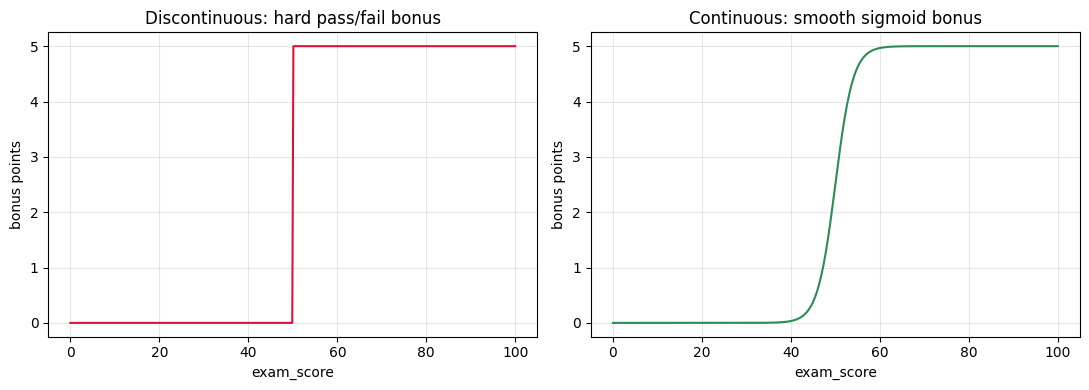

Left curve jumps at score=50 -> the limit from the left doesn't match the limit from the right.
Right curve has no jumps anywhere -> continuous, and (unlike the left one) differentiable too.


In [7]:
def pass_fail_bonus(score):
    '''A grading bonus that JUMPS at the pass threshold -- discontinuous.'''
    return np.where(score >= 50, 5, 0)

def smooth_bonus(score, k=0.5, midpoint=50):
    '''A smooth, continuous version using a sigmoid instead of a hard cutoff.'''
    return 5 / (1 + np.exp(-k * (score - midpoint)))

scores = np.linspace(0, 100, 400)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(scores, pass_fail_bonus(scores), color='crimson')
axes[0].set_title('Discontinuous: hard pass/fail bonus')
axes[0].set_xlabel('exam_score'); axes[0].set_ylabel('bonus points')

axes[1].plot(scores, smooth_bonus(scores), color='seagreen')
axes[1].set_title('Continuous: smooth sigmoid bonus')
axes[1].set_xlabel('exam_score'); axes[1].set_ylabel('bonus points')

plt.tight_layout()
plt.show()

print("Left curve jumps at score=50 -> the limit from the left doesn't match the limit from the right.")
print("Right curve has no jumps anywhere -> continuous, and (unlike the left one) differentiable too.")

**🎯 Try it yourself**
1. Is $f(x) = \frac{\sin x}{x}$ continuous at $x=0$? Compare `sp.limit(sp.sin(x)/x, x, 0)` to what $f(0)$ would naively be.
2. Using `df`, does `exam_score` look like it changes smoothly with `attendance_pct`, or are there any natural "jumps"?

**Key takeaway:** limits let us reason about a function's behavior *near* a point without needing the function to be defined (or well-behaved) exactly there — that's exactly the trick the derivative uses next.

<a id="sec2"></a>
## 2. Derivatives
*Importance: 🔴 Critical*

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

The derivative is the **instantaneous rate of change** of $f$ at $x$ — the slope of the tangent line. In practice you rarely apply the limit definition by hand; instead you use rules:

| Rule | Formula |
|---|---|
| Power | $\dfrac{d}{dx} x^n = n x^{n-1}$ |
| Sum | $(f+g)' = f'+g'$ |
| Product | $(fg)' = f'g + fg'$ |
| Quotient | $\left(\dfrac{f}{g}\right)' = \dfrac{f'g - fg'}{g^2}$ |

**Why it matters for data science:** the derivative tells you which direction is "downhill" on a loss surface — that single idea is what gradient descent (Section 5) is built on.

In [26]:
def f_demo(x):
    return x**3 - 2*x

def numerical_derivative(f, x0, h):
    return (f(x0 + h) - f(x0)) / h

x0 = 2.0
print(f"Estimating f'({x0}) for f(x) = x^3 - 2x, straight from the limit definition:\n")
for h in [1, 0.1, 0.01, 0.0001, 1e-7]:
    print(f"h = {h:<10} -> {numerical_derivative(f_demo, x0, h):.6f}")

exact = float(sp.diff(x**3 - 2*x, x).subs(x, x0))
print(f"\nExact (symbolic) derivative at x={x0}: {exact}")

Estimating f'(2.0) for f(x) = x^3 - 2x, straight from the limit definition:

h = 1          -> 17.000000
h = 0.1        -> 10.610000
h = 0.01       -> 10.060100
h = 0.0001     -> 10.000600
h = 1e-07      -> 10.000001

Exact (symbolic) derivative at x=2.0: 10.0


In [9]:
f1, g1 = x**3, sp.sin(x)

print("Power rule:    d/dx[x^3]          =", sp.diff(x**3, x))
print("Product rule:  d/dx[x^3 * sin(x)] =", sp.diff(f1 * g1, x))
print("Quotient rule: d/dx[x^3 / sin(x)] =", sp.diff(f1 / g1, x))
print("Sum rule:      d/dx[x^3 + sin(x)] =", sp.diff(f1 + g1, x))

Power rule:    d/dx[x^3]          = 3*x**2
Product rule:  d/dx[x^3 * sin(x)] = x**3*cos(x) + 3*x**2*sin(x)
Quotient rule: d/dx[x^3 / sin(x)] = -x**3*cos(x)/sin(x)**2 + 3*x**2/sin(x)
Sum rule:      d/dx[x^3 + sin(x)] = 3*x**2 + cos(x)


Fitted curve: score(h) = -0.170 h^2 + 2.312 h + 52.408
score'(h) = 2.312 - 0.3407*h
Derivative hits zero at h = 6.79 study hours -> extra studying past this stops helping


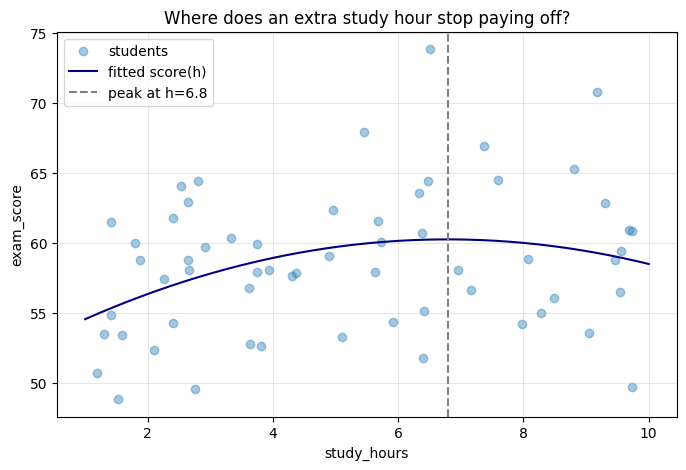

In [27]:
# Fit a quadratic to exam_score vs study_hours (matches how the data was generated)
coeffs = np.polyfit(df['study_hours'], df['exam_score'], 2)
a2, a1, a0 = [float(c) for c in coeffs]
print(f"Fitted curve: score(h) = {a2:.3f} h^2 + {a1:.3f} h + {a0:.3f}")

h_sym = sp.Symbol('h')
score_expr = a2 * h_sym**2 + a1 * h_sym + a0
score_deriv = sp.diff(score_expr, h_sym)
critical_h = float(sp.solve(sp.Eq(score_deriv, 0), h_sym)[0])

print(f"score'(h) = {score_deriv.evalf(4)}")
print(f"Derivative hits zero at h = {critical_h:.2f} study hours -> extra studying past this stops helping")

hs = np.linspace(1, 10, 200)
fitted = np.polyval(coeffs, hs)

fig, ax = plt.subplots()
ax.scatter(df['study_hours'], df['exam_score'], alpha=0.4, label='students')
ax.plot(hs, fitted, color='navy', label='fitted score(h)')
ax.axvline(critical_h, color='gray', linestyle='--', label=f'peak at h={critical_h:.1f}')
ax.set_xlabel('study_hours'); ax.set_ylabel('exam_score')
ax.legend()
plt.title("Where does an extra study hour stop paying off?")
plt.show()

**🎯 Try it yourself**
1. Change `f_demo` to $x^2 \sin(x)$ and re-run the limit-definition loop — does it converge to what `sp.diff` gives you?
2. What does it mean, in plain English, that `score_deriv` is *positive* for `h < critical_h` and *negative* after it?

**Key takeaway:** the derivative turns "how is this changing?" into a number you can compute — and setting it to zero is how you find peaks, valleys, and (soon) trained model parameters.

<a id="sec3"></a>
## 3. Partial Derivatives
*Importance: 🔴 Critical*

For a multivariable function $f(x,y)$, the partial derivative with respect to $x$ treats every other variable as a constant:

$$\frac{\partial f}{\partial x} = \lim_{h \to 0} \frac{f(x+h, y) - f(x, y)}{h}$$

and likewise for $\frac{\partial f}{\partial y}$. Geometrically, $\frac{\partial f}{\partial x}$ is the slope of the surface $z=f(x,y)$ if you slice it with a plane at fixed $y$ and walk along $x$.

**Why it matters for data science:** any model with more than one input feature needs partial derivatives — a loss function of $n$ parameters has $n$ partial derivatives, one per parameter, and together they form the gradient (Section 5).

In [11]:
f_xy = x**2 * y + sp.sin(y) * x

df_dx = sp.diff(f_xy, x)
df_dy = sp.diff(f_xy, y)

print(f"f(x,y) = {f_xy}")
print(f"df/dx  = {df_dx}")
print(f"df/dy  = {df_dy}")
print(f"\nAt (x,y) = (2,1): df/dx = {df_dx.subs({x: 2, y: 1})}, df/dy = {df_dy.subs({x: 2, y: 1})}")

f(x,y) = x**2*y + x*sin(y)
df/dx  = 2*x*y + sin(y)
df/dy  = x**2 + x*cos(y)

At (x,y) = (2,1): df/dx = sin(1) + 4, df/dy = 2*cos(1) + 4


Fitted model: score = 46.22 + 0.48*study_hours + 0.13*attendance_pct

d(score)/d(study_hours) = 0.48   (holding attendance_pct fixed)
d(score)/d(attendance_pct)  = 0.13   (holding study_hours fixed)

Because the model is linear, these partials are just the coefficients themselves -- constant everywhere.


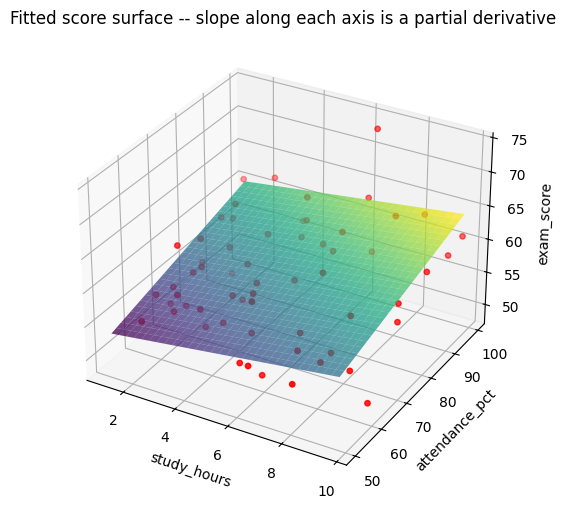

In [29]:
# Fit exam_score ~ study_hours + sleep_hours (closed-form multiple linear regression)
X = np.column_stack([np.ones(n), df['study_hours'], df['attendance_pct']])
y_target = df['exam_score'].values
beta, *_ = np.linalg.lstsq(X, y_target, rcond=None)
mb0, mb1, mb2 = beta

print(f"Fitted model: score = {mb0:.2f} + {mb1:.2f}*study_hours + {mb2:.2f}*attendance_pct")
print(f"\nd(score)/d(study_hours) = {mb1:.2f}   (holding attendance_pct fixed)")
print(f"d(score)/d(attendance_pct)  = {mb2:.2f}   (holding study_hours fixed)")
print("\nBecause the model is linear, these partials are just the coefficients themselves -- constant everywhere.")

sh_range = np.linspace(df['study_hours'].min(), df['study_hours'].max(), 30)
at_range = np.linspace(df['attendance_pct'].min(), df['attendance_pct'].max(), 30)
SH, AT = np.meshgrid(sh_range, at_range)
SCORE = mb0 + mb1 * SH + mb2 * AT

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(SH, AT, SCORE, cmap='viridis', alpha=0.75)
ax.scatter(df['study_hours'], df['attendance_pct'], df['exam_score'], color='red', s=15)
ax.set_xlabel('study_hours'); ax.set_ylabel('attendance_pct'); ax.set_zlabel('exam_score')
ax.set_title('Fitted score surface -- slope along each axis is a partial derivative')
plt.show()

**🎯 Try it yourself**
1. Add `attendance_pct` as a third feature to the regression — what's $\partial(\text{score})/\partial(\text{attendance\_pct})$?
2. For $f(x,y)=x^2y+\sin(y)\,x$ above, is $\partial f/\partial x$ ever equal to $\partial f/\partial y$ for some $(x,y)$? (Try solving it with `sp.solve`.)

**Key takeaway:** a partial derivative is just an ordinary derivative that's agreed to ignore every variable except one — do that once per variable and you get a full multivariable picture.

<a id="sec4"></a>
## 4. Integrals
*Importance: 🟡 Important*

The **indefinite integral** $\int f(x)\,dx = F(x) + C$ is the antiderivative — reversing differentiation. The **definite integral** $\int_a^b f(x)\,dx$ is the signed area under $f$ between $a$ and $b$.

**Fundamental Theorem of Calculus:** $\int_a^b f(x)\,dx = F(b) - F(a)$, where $F' = f$. This is the bridge that makes derivatives and integrals inverse operations of each other.

**Why it matters for data science:** integrals show up whenever you need a total built from a rate — area under an ROC curve, expected values of continuous random variables, and cumulative distribution functions are all integrals.

Indefinite integral of (x^2 + 1) dx        = x**3/3 + x + C
Definite integral, 0 to 3, of (x^2+1) dx   = 12
Trapezoidal-rule estimate: 12.00000


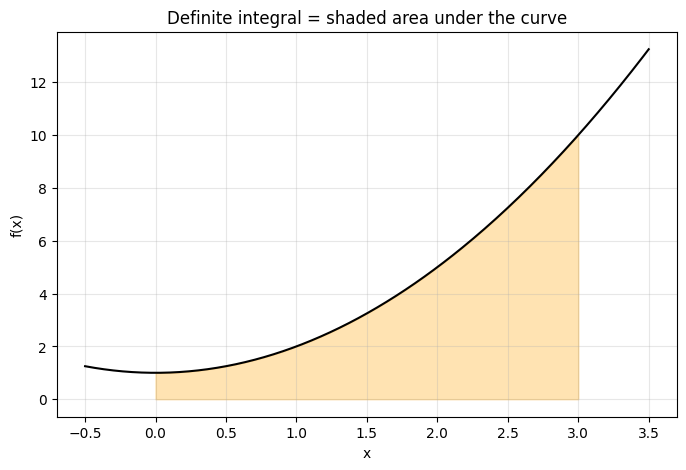

In [13]:
f_int = x**2 + 1

indefinite = sp.integrate(f_int, x)
definite = sp.integrate(f_int, (x, 0, 3))
print(f"Indefinite integral of (x^2 + 1) dx        = {indefinite} + C")
print(f"Definite integral, 0 to 3, of (x^2+1) dx   = {definite}")

# Numeric check via the trapezoidal rule
xs = np.linspace(0, 3, 10000)
ys = xs**2 + 1
numeric_area = np.trapezoid(ys, xs)
print(f"Trapezoidal-rule estimate: {numeric_area:.5f}")

xs_fine = np.linspace(-0.5, 3.5, 300)
plt.plot(xs_fine, xs_fine**2 + 1, color='black')
fill_x = np.linspace(0, 3, 300)
plt.fill_between(fill_x, fill_x**2 + 1, alpha=0.3, color='orange')
plt.title("Definite integral = shaded area under the curve")
plt.xlabel('x'); plt.ylabel('f(x)')
plt.show()

In [14]:
# Full circle: integrate Section 2's derivative and land back on its score(h)
recovered = sp.integrate(score_deriv, h_sym)
print(f"score'(h)            = {score_deriv.evalf(4)}")
print(f"Integral of score'(h) = {recovered.evalf(4)} + C")
print(f"Original score(h)     = {sp.expand(score_expr).evalf(4)}")
print("\n-> integrating undoes differentiating (up to the +C), exactly as the Fundamental Theorem promises.")

score'(h)            = 2.312 - 0.3407*h
Integral of score'(h) = -0.1703*h**2 + 2.312*h + C
Original score(h)     = -0.1703*h**2 + 2.312*h + 52.41

-> integrating undoes differentiating (up to the +C), exactly as the Fundamental Theorem promises.


**🎯 Try it yourself**
1. What's $\int_1^{10}$ `score(h)` $dh$? (This would be the "total expected score" integrated across all possible study-hour levels — not something you'd normally compute, but a good sympy exercise.)
2. Try `np.trapz` with only 10 points instead of 10000 for the $x^2+1$ example — how much does the estimate degrade?

**Key takeaway:** derivatives and integrals are inverse operations — one tells you the rate, the other rebuilds the total from the rate.

<a id="sec5"></a>
## 5. Gradient Descent
*Importance: 🔴 Critical*

$$\nabla f = \left[\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \dots, \frac{\partial f}{\partial x_n}\right]$$

The gradient points in the direction of steepest **increase**. To minimize a loss function, step in the opposite direction:

$$\theta \leftarrow \theta - \alpha \, \nabla L(\theta)$$

where $\alpha$ is the learning rate. Repeat until the gradient is ~0 (a minimum) or you run out of patience.

**Why it matters for data science:** this is how almost every model you'll ever train actually learns — linear regression, logistic regression, and every neural network use some flavor of this update rule.

Gradient descent result after 200 iterations: b0=58.565, b1=1.194
Closed-form (np.polyfit) result:               b0=58.565, b1=1.194


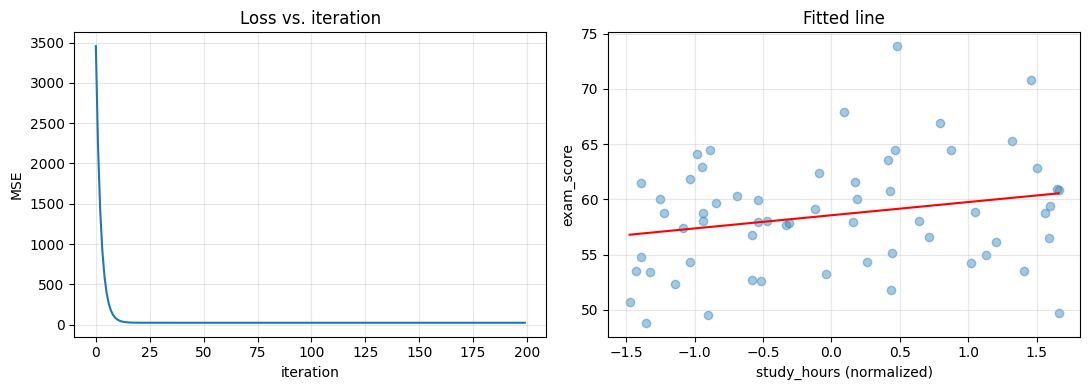

In [15]:
# Simple linear regression via gradient descent: score = b0 + b1*study_hours
sh = df['study_hours'].values
sc = df['exam_score'].values
sh_norm = (sh - sh.mean()) / sh.std()   # normalizing helps gradient descent converge

b0, b1 = 0.0, 0.0
alpha = 0.1
n_iters = 200
loss_history = []

for i in range(n_iters):
    pred = b0 + b1 * sh_norm
    error = pred - sc
    loss = np.mean(error**2)
    loss_history.append(loss)
    grad_b0 = 2 * np.mean(error)
    grad_b1 = 2 * np.mean(error * sh_norm)
    b0 -= alpha * grad_b0
    b1 -= alpha * grad_b1

print(f"Gradient descent result after {n_iters} iterations: b0={b0:.3f}, b1={b1:.3f}")

b1_closed, b0_closed = np.polyfit(sh_norm, sc, 1)
print(f"Closed-form (np.polyfit) result:               b0={b0_closed:.3f}, b1={b1_closed:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(loss_history)
axes[0].set_title('Loss vs. iteration'); axes[0].set_xlabel('iteration'); axes[0].set_ylabel('MSE')

order = np.argsort(sh_norm)
axes[1].scatter(sh_norm, sc, alpha=0.4)
axes[1].plot(sh_norm[order], b0 + b1 * sh_norm[order], color='red')
axes[1].set_title('Fitted line'); axes[1].set_xlabel('study_hours (normalized)'); axes[1].set_ylabel('exam_score')
plt.tight_layout()
plt.show()

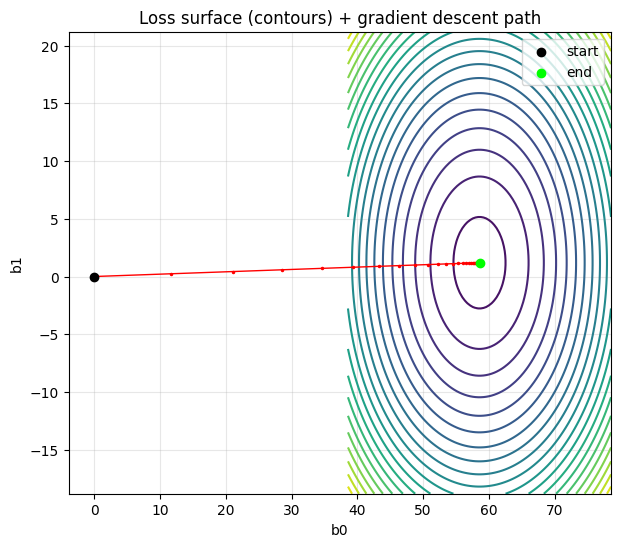

In [16]:
# Bonus: visualize the loss surface itself, with the gradient descent path walked across it
b0_range = np.linspace(b0 - 20, b0 + 20, 100)
b1_range = np.linspace(b1 - 20, b1 + 20, 100)
B0, B1 = np.meshgrid(b0_range, b1_range)
LOSS = np.zeros_like(B0)
for i in range(B0.shape[0]):
    for j in range(B0.shape[1]):
        pred = B0[i, j] + B1[i, j] * sh_norm
        LOSS[i, j] = np.mean((pred - sc)**2)

path_b0, path_b1 = [0.0], [0.0]
pb0, pb1 = 0.0, 0.0
for i in range(n_iters):
    pred = pb0 + pb1 * sh_norm
    error = pred - sc
    pb0 -= alpha * 2 * np.mean(error)
    pb1 -= alpha * 2 * np.mean(error * sh_norm)
    path_b0.append(pb0); path_b1.append(pb1)

plt.figure(figsize=(7, 6))
plt.contour(B0, B1, LOSS, levels=25, cmap='viridis')
plt.plot(path_b0, path_b1, color='red', marker='.', markersize=3, linewidth=1)
plt.scatter([path_b0[0]], [path_b1[0]], color='black', zorder=5, label='start')
plt.scatter([path_b0[-1]], [path_b1[-1]], color='lime', zorder=5, label='end')
plt.xlabel('b0'); plt.ylabel('b1'); plt.title('Loss surface (contours) + gradient descent path')
plt.legend()
plt.show()

**🎯 Try it yourself**
1. Set `alpha = 1.5` and re-run — what happens to the loss curve? (This is what "diverging" looks like.)
2. Set `alpha = 0.001` instead — does it still reach the same `b0, b1` within 200 iterations?

**Key takeaway:** gradient descent is nothing more than "compute the slope, step downhill, repeat" — the contour plot above is literally that process happening in two dimensions.

<a id="sec6"></a>
## 6. Chain Rule
*Importance: 🔴 Critical*

$$\frac{d}{dx}\big[f(g(x))\big] = f'(g(x)) \cdot g'(x)$$

To differentiate a composition of functions, differentiate the "outside" function (leaving the inside alone), then multiply by the derivative of the "inside."

**Why it matters for data science:** a neural network is one long composition of functions (layer after layer). Backpropagation is nothing more than the chain rule applied repeatedly, working backward from the loss to each weight.

In [17]:
g_x = x**2 + 1
f_g = sp.sin(g_x)   # f(g(x)) = sin(x^2 + 1)

direct = sp.diff(f_g, x)
manual = sp.diff(sp.sin(y), y).subs(y, g_x) * sp.diff(g_x, x)

print("f(g(x)) = sin(x^2 + 1)")
print(f"Direct sympy diff:          {direct}")
print(f"Manual f'(g(x)) * g'(x):    {sp.simplify(manual)}")
print(f"Match: {sp.simplify(direct - manual) == 0}")

f(g(x)) = sin(x^2 + 1)
Direct sympy diff:          2*x*cos(x**2 + 1)
Manual f'(g(x)) * g'(x):    2*x*cos(x**2 + 1)
Match: True


In [18]:
# A 1-neuron "network": z = w*x + b, a = sigmoid(z), L = (a - target)^2
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

x_in, target = 2.0, 1.0
w_val, b_val = 0.5, 0.1

z = w_val * x_in + b_val
a = sigmoid(z)
L = (a - target)**2
print(f"Forward pass: z={z:.4f}, a={a:.4f}, L={L:.4f}\n")

# Backward pass via the chain rule: dL/dw = dL/da * da/dz * dz/dw
dL_da = 2 * (a - target)
da_dz = a * (1 - a)          # derivative of sigmoid
dz_dw = x_in
dL_dw_chainrule = dL_da * da_dz * dz_dw
print(f"dL/da={dL_da:.4f}, da/dz={da_dz:.4f}, dz/dw={dz_dw:.4f}")
print(f"dL/dw via chain rule:          {dL_dw_chainrule:.6f}")

# Sanity check against a numerical finite-difference gradient ("gradient checking")
eps = 1e-6
L_plus = (sigmoid((w_val + eps) * x_in + b_val) - target)**2
L_minus = (sigmoid((w_val - eps) * x_in + b_val) - target)**2
dL_dw_numeric = (L_plus - L_minus) / (2 * eps)
print(f"dL/dw via finite differences:  {dL_dw_numeric:.6f}")

Forward pass: z=1.1000, a=0.7503, L=0.0624

dL/da=-0.4995, da/dz=0.1874, dz/dw=2.0000
dL/dw via chain rule:          -0.187175
dL/dw via finite differences:  -0.187175


**🎯 Try it yourself**
1. Add a second layer ($z_2 = w_2 \cdot a_1 + b_2$, $a_2 = \text{sigmoid}(z_2)$) and extend the chain rule computation to find $dL/dw_1$.
2. Why does "gradient checking" (comparing the chain-rule result to finite differences) matter when you're implementing backprop by hand?

**Key takeaway:** backpropagation has no separate magic — it's the chain rule, applied once per layer, computed back-to-front.

<a id="sec7"></a>
## 7. Jacobians and Hessians
*Importance: 🟡 Important*

- **Jacobian** — for a vector-valued function $F: \mathbb{R}^n \to \mathbb{R}^m$, the matrix of all first partial derivatives: $J_{ij} = \dfrac{\partial F_i}{\partial x_j}$.
- **Hessian** — for a scalar function $f: \mathbb{R}^n \to \mathbb{R}$, the (square, symmetric) matrix of all second partial derivatives: $H_{ij} = \dfrac{\partial^2 f}{\partial x_i \partial x_j}$. It describes curvature.

**Why it matters for data science:** the Hessian tells you whether a loss surface is convex (a bowl, where gradient descent is guaranteed to find the *global* minimum) or has saddle points and multiple minima. Second-order optimizers (Newton's method, L-BFGS) use the Hessian directly instead of just the gradient.

In [19]:
x1, x2 = sp.symbols('x1 x2')
F = sp.Matrix([x1**2 * x2, x1 + x2**3])
J = F.jacobian([x1, x2])

print("F(x1,x2) =")
sp.pprint(F.T)
print("\nJacobian J =")
sp.pprint(J)
print("\nJ at (x1,x2)=(1,2):")
sp.pprint(J.subs({x1: 1, x2: 2}))

F(x1,x2) =
⎡  2            3⎤
⎣x₁ ⋅x₂  x₁ + x₂ ⎦

Jacobian J =
⎡            2 ⎤
⎢2⋅x₁⋅x₂   x₁  ⎥
⎢              ⎥
⎢             2⎥
⎣   1     3⋅x₂ ⎦

J at (x1,x2)=(1,2):
⎡4  1 ⎤
⎢     ⎥
⎣1  12⎦

⎡  2            3⎤
⎣x₁ ⋅x₂  x₁ + x₂ ⎦

Jacobian J =
⎡            2 ⎤
⎢2⋅x₁⋅x₂   x₁  ⎥
⎢              ⎥
⎢             2⎥
⎣   1     3⋅x₂ ⎦

J at (x1,x2)=(1,2):
⎡4  1 ⎤
⎢     ⎥
⎣1  12⎦


In [20]:
# Hessian of the Section 5 MSE loss L(b0,b1) -- is it convex?
b0_s, b1_s = sp.symbols('b0 b1')
sh_sample = [float(v) for v in sh_norm[:10]]
sc_sample = [float(v) for v in sc[:10]]

L_expr = sum((b0_s + b1_s * sh_i - sc_i)**2 for sh_i, sc_i in zip(sh_sample, sc_sample)) / len(sh_sample)

H = sp.hessian(L_expr, (b0_s, b1_s))
print("Hessian of the MSE loss w.r.t. (b0, b1):")
sp.pprint(sp.simplify(H))

H_numeric = np.array([[float(H[i, j]) for j in range(H.shape[1])] for i in range(H.shape[0])])
eigenvalues = np.linalg.eigvals(H_numeric)
print(f"\nEigenvalues: {eigenvalues}")
print("Both positive -> the loss surface is convex -> gradient descent finds THE minimum, not just A minimum.")

Hessian of the MSE loss w.r.t. (b0, b1):
⎡        2          0.346897099593003⎤
⎢                                    ⎥
⎣0.346897099593003  2.02124713005943 ⎦

Eigenvalues: [1.66356383 2.3576833 ]
Both positive -> the loss surface is convex -> gradient descent finds THE minimum, not just A minimum.


**🎯 Try it yourself**
1. Compute the Jacobian of $F(x_1,x_2) = [x_1 x_2,\ x_1^2 - x_2^2,\ \sin(x_1 x_2)]$ — note it's now a 3x2 matrix, not square.
2. A Hessian with one positive and one negative eigenvalue signals a **saddle point** — why would that be bad news for a plain gradient descent run?

**Key takeaway:** the gradient (Section 5) tells you the slope; the Hessian tells you the *curvature* — and curvature is what separates a simple bowl shape from a surface riddled with saddle-point traps.

<a id="sec8"></a>
## 8. Taylor Series
*Importance: 🟡 Important*

$$f(x) = f(a) + f'(a)(x-a) + \frac{f''(a)}{2!}(x-a)^2 + \frac{f'''(a)}{3!}(x-a)^3 + \dots$$

A Taylor series approximates any smooth function near a point $a$ using a polynomial built from its derivatives at that point. The more terms you include, the wider the region where the approximation stays accurate.

**Why it matters for data science:** a first-order Taylor expansion of a loss function is exactly what a single gradient descent step assumes locally. A second-order expansion is what Newton's method uses — the Hessian from Section 7 *is* the quadratic term.

f(x) = e^x, expanded around x=0:
Order 1: x + 1
Order 2: x**2/2 + x + 1
Order 4: x**4/24 + x**3/6 + x**2/2 + x + 1


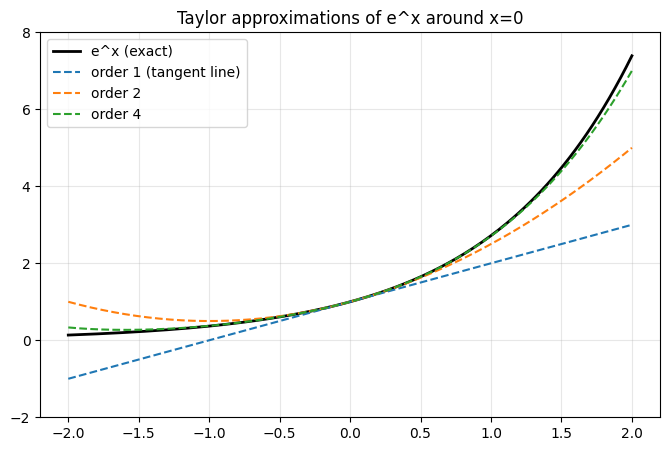

In [21]:
f_taylor = sp.exp(x)
a_point = 0

t1 = f_taylor.series(x, a_point, 2).removeO()   # order 1 (tangent line)
t2 = f_taylor.series(x, a_point, 3).removeO()   # order 2 (quadratic)
t4 = f_taylor.series(x, a_point, 5).removeO()   # order 4

print("f(x) = e^x, expanded around x=0:")
print(f"Order 1: {t1}")
print(f"Order 2: {t2}")
print(f"Order 4: {t4}")

f_num = sp.lambdify(x, f_taylor)
t1_num = sp.lambdify(x, t1)
t2_num = sp.lambdify(x, t2)
t4_num = sp.lambdify(x, t4)

xs = np.linspace(-2, 2, 200)
plt.plot(xs, f_num(xs), label='e^x (exact)', color='black', linewidth=2)
plt.plot(xs, t1_num(xs), '--', label='order 1 (tangent line)')
plt.plot(xs, t2_num(xs), '--', label='order 2')
plt.plot(xs, t4_num(xs), '--', label='order 4')
plt.ylim(-2, 8)
plt.legend()
plt.title("Taylor approximations of e^x around x=0")
plt.show()

Fitted score(h) around h=5.21:
Order-1 Taylor (tangent line): 0.5381*h + 57.03


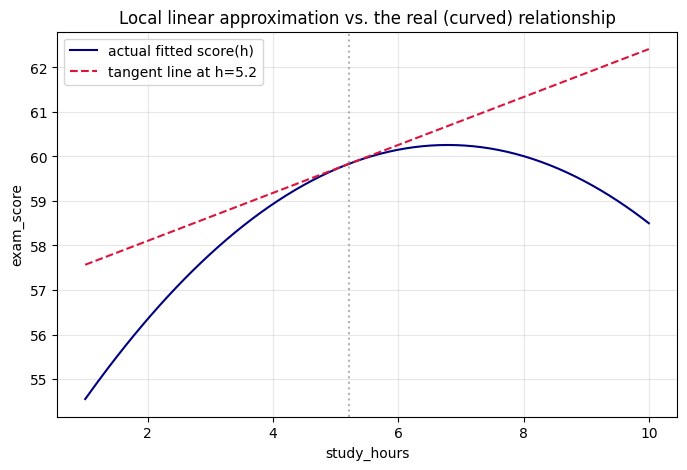


The tangent line matches closely near h=5.2 but drifts away further out --
this is exactly why optimizers need to keep re-evaluating the gradient at each new point.


In [22]:
# Callback to Section 2: approximate the fitted score(h) curve with its tangent line
mean_h = float(df['study_hours'].mean())
f_at_mean = float(score_expr.subs(h_sym, mean_h))
fprime_at_mean = float(score_deriv.subs(h_sym, mean_h))
tangent = f_at_mean + fprime_at_mean * (h_sym - mean_h)   # f(a) + f'(a)(h-a), straight from the formula above

print(f"Fitted score(h) around h={mean_h:.2f}:")
print(f"Order-1 Taylor (tangent line): {sp.expand(tangent).evalf(4)}")

hs2 = np.linspace(1, 10, 200)
actual_vals = np.polyval(coeffs, hs2)
tangent_fn = sp.lambdify(h_sym, tangent)
tangent_vals = tangent_fn(hs2)

plt.plot(hs2, actual_vals, label='actual fitted score(h)', color='navy')
plt.plot(hs2, tangent_vals, '--', label=f'tangent line at h={mean_h:.1f}', color='crimson')
plt.axvline(mean_h, color='gray', linestyle=':', alpha=0.6)
plt.legend(); plt.xlabel('study_hours'); plt.ylabel('exam_score')
plt.title('Local linear approximation vs. the real (curved) relationship')
plt.show()

print(f"\nThe tangent line matches closely near h={mean_h:.1f} but drifts away further out --")
print("this is exactly why optimizers need to keep re-evaluating the gradient at each new point.")

**🎯 Try it yourself**
1. Expand `score_expr` to order 2 (a quadratic Taylor expansion) around `mean_h` — since `score_expr` is already a quadratic, what do you notice?
2. At which $x$ values does the order-1 approximation of $e^x$ visibly diverge from the real curve in the plot above?

**Key takeaway:** every optimizer that isn't brute-force search is, at its core, repeatedly building a small local Taylor approximation of the loss and trusting it just long enough to take one step.

## Wrap-up

| Topic | Core idea | Where it resurfaces |
|---|---|---|
| Limits & Continuity | Behavior *near* a point | Foundation for every derivative below |
| Derivatives | Instantaneous rate of change | Everywhere |
| Partial Derivatives | Rate of change, one variable at a time | Regression coefficients, gradients |
| Integrals | Accumulation / area, inverse of a derivative | AUC, expected value, undoing a derivative |
| Gradient Descent | Step downhill using the gradient | How virtually every model is trained |
| Chain Rule | Derivative of a composition | Backpropagation |
| Jacobians & Hessians | First/second derivatives in matrix form | Convexity checks, Newton's method |
| Taylor Series | Local polynomial approximation | Why gradient steps and Newton's method work at all |

A natural next step from here is **Probability & Statistics for Data Science**, or going deeper into optimization (momentum, Adam, second-order methods) now that gradients, Jacobians, and Hessians are all on the table.